In [ ]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/online_retail_cleaned.csv")

In [ ]:
df.shape

(535187, 8)

In [ ]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,united kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,united kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,united kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,united kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,united kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535187 entries, 0 to 535186
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    535187 non-null  object 
 1   stockcode    535187 non-null  object 
 2   description  535187 non-null  object 
 3   quantity     535187 non-null  int64  
 4   invoicedate  535187 non-null  object 
 5   unitprice    535187 non-null  float64
 6   customerid   401604 non-null  float64
 7   country      535187 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [ ]:
df.describe()

,quantity,unitprice,customerid
count,535187.000000,535187.000000,401604.000000
mean,9.671593,4.645242,15281.160818
std,219.059056,97.364810,1714.006089
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13939.000000
50%,3.000000,2.080000,15145.000000
75%,10.000000,4.130000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

In [ ]:
df["invoiceno"].isnull().sum()
df["unitprice"].isnull().sum()

np.int64(0)

In [ ]:
df["quantity"].sum()

np.int64(5176111)

In [ ]:
df["revenue"]=df["unitprice"] * df["quantity"]

In [ ]:
df["revenue"].sum()

np.float64(9726006.954)

In [ ]:
(df[["quantity","unitprice","revenue"]].describe())

,quantity,unitprice,revenue
count,535187.000000,535187.000000,535187.000000
mean,9.671593,4.645242,18.173100
std,219.059056,97.364810,381.171824
min,-80995.000000,-11062.060000,-168469.600000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.900000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


In [ ]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'revenue'],
      dtype='object')

In [ ]:
#Key business metrics
print("total revenue:",df["revenue"].sum())
print("total quantity:",df["quantity"].sum())
print("unique customer id:",df["customerid"].nunique())
print("countries:",df["country"].nunique())
print("transaction:",df["invoiceno"].nunique())


total revenue: 9726006.954
total quantity: 5176111
unique customer id: 4372
countries: 38
transaction: 24446


In [ ]:
df["invoicedate"] = pd.to_datetime(
    df["invoicedate"],
    format="mixed",
    errors="coerce"
)

In [ ]:
(df["invoicedate"].dtypes)

dtype('<M8[ns]')

In [ ]:
monthly_revenue = (
    df.groupby(df["invoicedate"].dt.to_period("M"))["revenue"]
    .sum()
)

In [ ]:
monthly_revenue

,revenue
invoicedate,
2010-12,746723.610
2011-01,558448.560
2011-02,497026.410
2011-03,682013.980
2011-04,492367.841
2011-05,722094.100
2011-06,689977.230
2011-07,680156.991
2011-08,681386.460


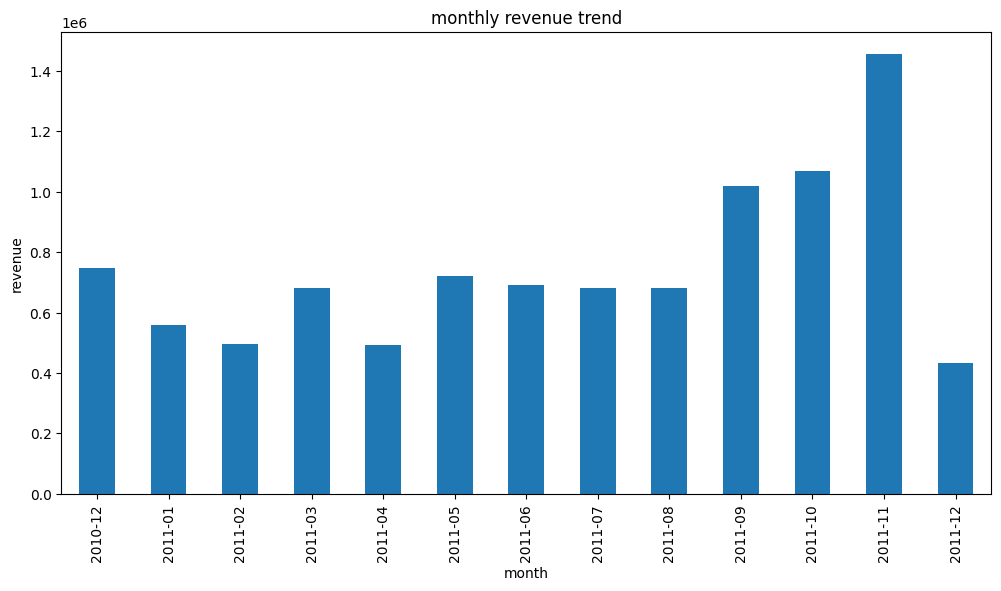

In [ ]:
monthly_revenue.plot(
    kind="bar",

    figsize=(12,6)
)
plt.title("monthly revenue trend")
plt.xlabel("month")
plt.ylabel("revenue")
plt.show()

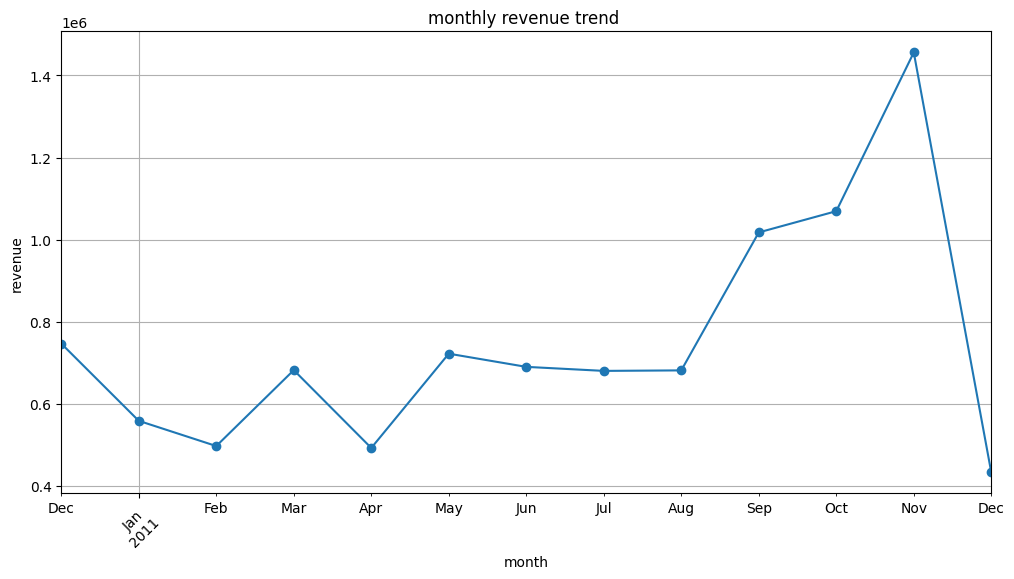

In [ ]:
monthly_revenue.plot(
    kind="line",
    marker="o",
    figsize=(12,6)
)
plt.title("monthly revenue trend ")
plt.xlabel("month")
plt.ylabel("revenue")
plt.grid()
plt.xticks(rotation=45)
plt.show()

In [ ]:
top_products = (
    df.groupby("description")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: revenue, dtype: float64


In [ ]:
top_products=(
    df.groupby("description")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


In [ ]:
top_products

,revenue
description,
DOTCOM POSTAGE,206245.48
REGENCY CAKESTAND 3 TIER,164459.49
WHITE HANGING HEART T-LIGHT HOLDER,99612.42
PARTY BUNTING,98243.88
JUMBO BAG RED RETROSPOT,92175.79
RABBIT NIGHT LIGHT,66661.63
POSTAGE,66230.64
PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
ASSORTED COLOUR BIRD ORNAMENT,58792.42


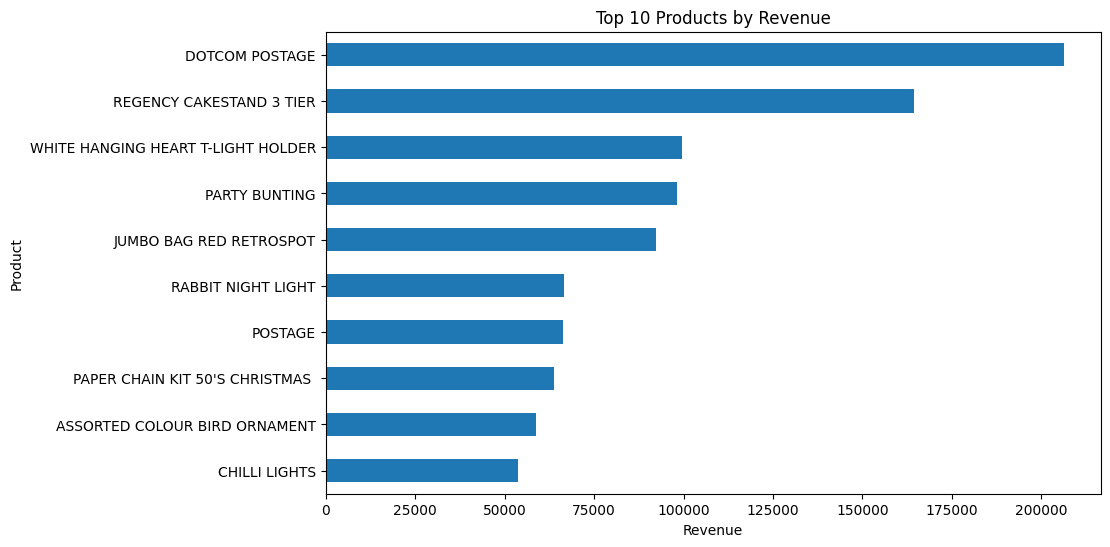

In [ ]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

In [ ]:
#. Top 10 Countries by Revenue
top_countries=(
    df.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [ ]:
top_countries


,revenue
country,
united kingdom,8167128.184
netherlands,284661.540
eire,262993.380
germany,221509.470
france,197317.110
australia,137009.770
switzerland,56363.050
spain,54756.030
belgium,40910.960


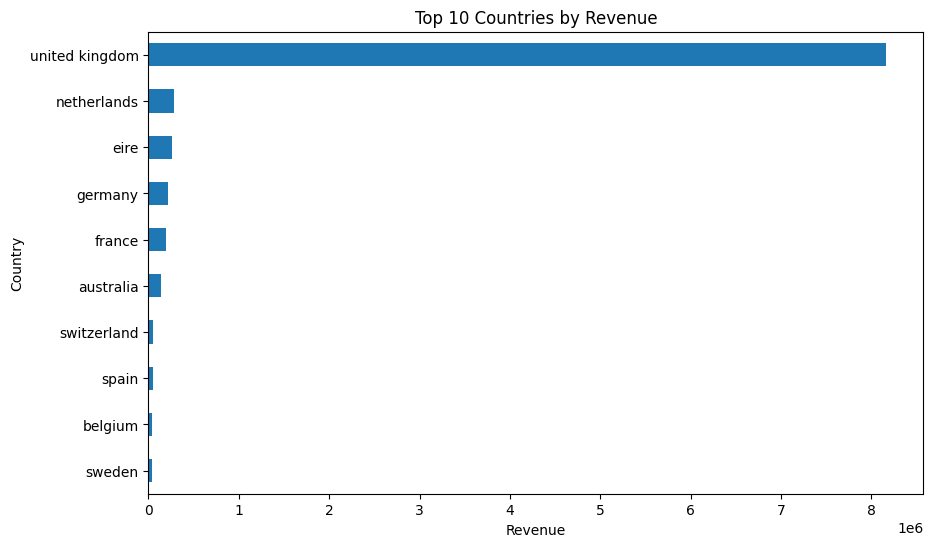

In [ ]:
top_countries.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

In [ ]:
#Revenue by Day of Week
df["day"]=df["invoicedate"].dt.day_name()
day_revenue=(
    df.groupby("day")["revenue"]
    .sum()
    .reindex(["Monday","Thurday","Wednesday","Tuesday","Friday","Saturday","Sunday"])
)



In [ ]:
df["day"].head(30)

,day
0,Wednesday
1,Wednesday
2,Wednesday
3,Wednesday
4,Wednesday
5,Wednesday
6,Wednesday
7,Wednesday
8,Wednesday
9,Wednesday


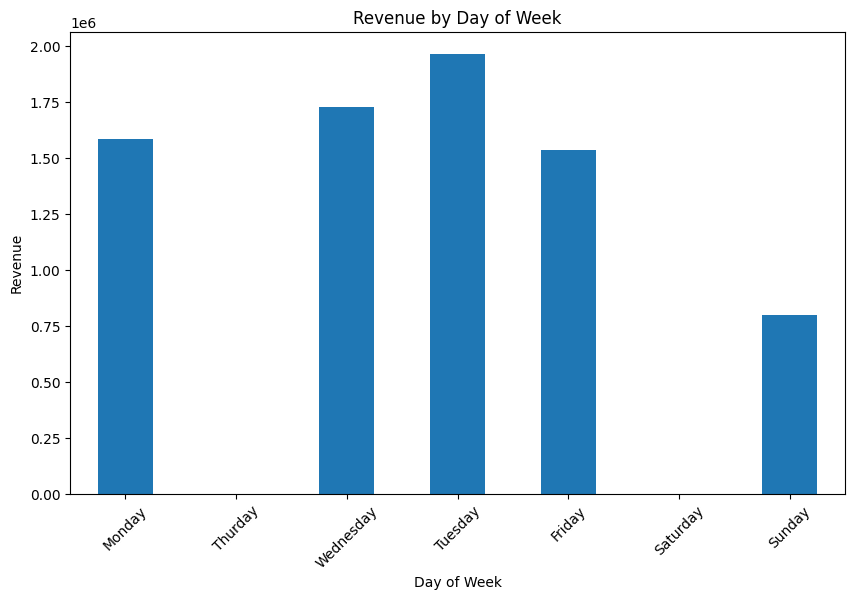

In [ ]:
day_revenue.plot(kind="bar",figsize=(10,6))
plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

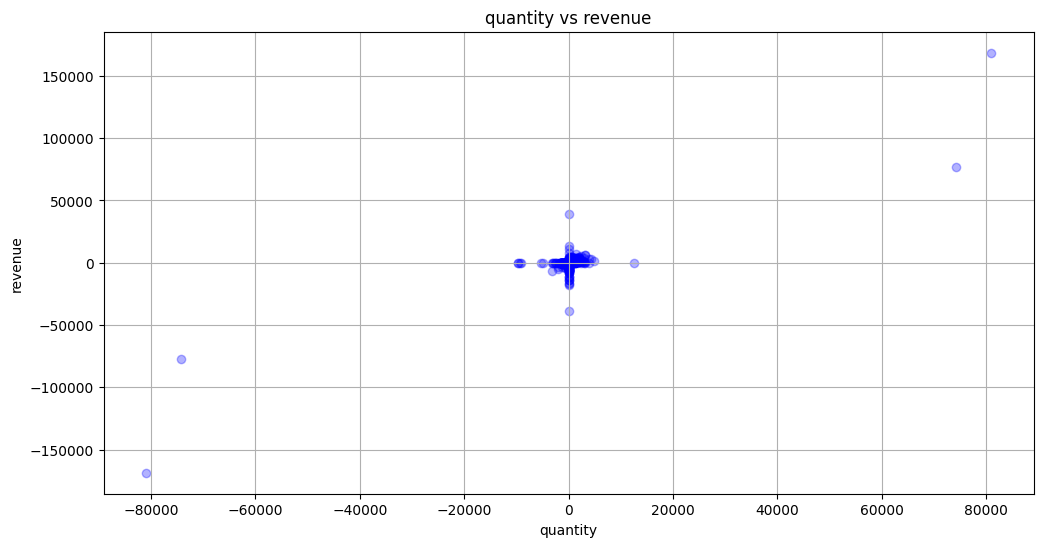

In [ ]:
#Quantity vs Revenue
plt.figure(figsize=(12,6))
plt.scatter(df["quantity"],df["revenue"],alpha=0.3,color="blue")
plt.title("quantity vs revenue")
plt.xlabel("quantity")

plt.ylabel("revenue")
plt.grid()
plt.show()

In [ ]:
print("maximum quantity:",df["quantity"].max())
print("minimum quantity:",df["quantity"].min())
print("max revenue:",df["revenue"].max())
print("min revenue:",df["revenue"].min())
print("max unit price:",df["unitprice"].max())

maximum quantity: 80995
minimum quantity: -80995
max revenue: 168469.6
min revenue: -168469.6
max unit price: 38970.0


In [ ]:
#Product Quantity Analysis
top_quantity_products=(
    df.groupby("description")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)

)
print("top_quantity_products")

top_quantity_products


In [ ]:
top_quantity_products

,quantity
description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751
JUMBO BAG RED RETROSPOT,47260
POPCORN HOLDER,36322
ASSORTED COLOUR BIRD ORNAMENT,36282
PACK OF 72 RETROSPOT CAKE CASES,36016
WHITE HANGING HEART T-LIGHT HOLDER,35298
RABBIT NIGHT LIGHT,30631
MINI PAINT SET VINTAGE,26437
PACK OF 12 LONDON TISSUES,26299


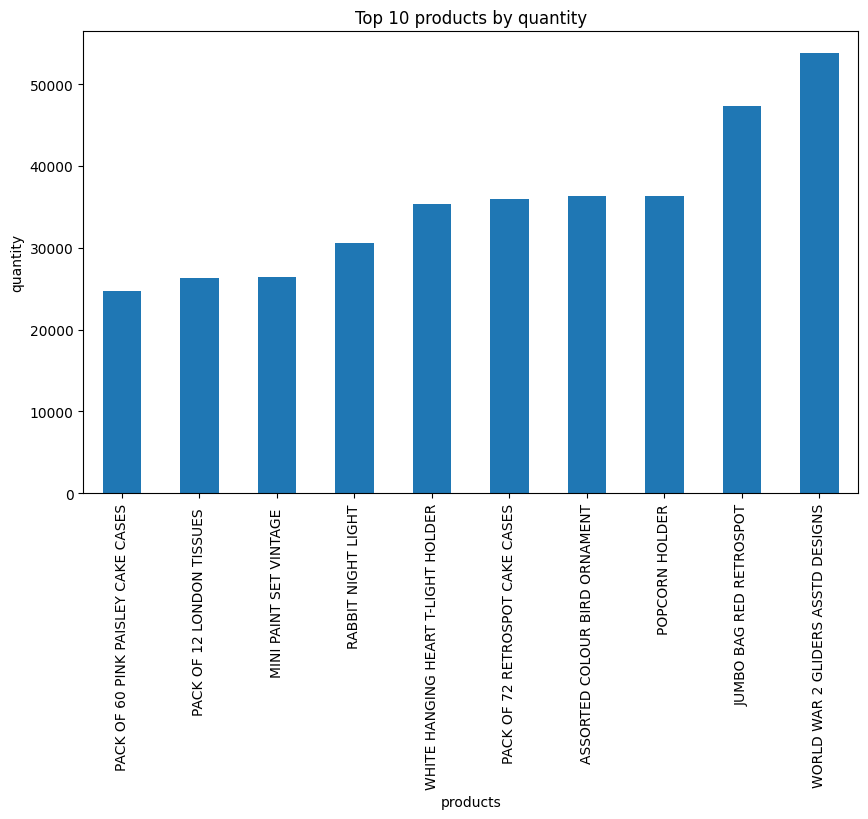

In [ ]:
top_quantity_products.sort_values().plot(kind="bar",figsize=(10,6))
plt.title("Top 10 products by quantity")
plt.ylabel("quantity")
plt.xlabel("products")
plt.show()

In [ ]:
## Key Insights


#1. Monthly revenue shows noticeable changes across the year, indicating seasonal purchasing patterns.

#2. A relatively small number of products contribute a large share of total revenue.

#3. The United Kingdom represents the largest revenue contribution among the countries in the dataset.

#4. Revenue varies across different days of the week, showing differences in purchasing activity.

#5. The dataset contains high-value transactions that appear as revenue outliers.

#6. Product demand varies considerably, with certain products accounting for much higher quantities sold.

In [ ]:
print("===== EDA SUMMARY =====")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Total Revenue:", df["revenue"].sum())
print("Total Quantity:", df["quantity"].sum())
print("Unique Products:", df["stockcode"].nunique())
print("Unique Customers:", df["customerid"].nunique())
print("Countries:", df["country"].nunique())


===== EDA SUMMARY =====
Rows: 535187
Columns: 10
Total Revenue: 9726006.954
Total Quantity: 5176111
Unique Products: 3958
Unique Customers: 4372
Countries: 38
